In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()
possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
from constants import FEATURES


# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd
from signal_region import get_SR_CR_cut, compute_sr_stats
from correct_systematic_error import get_histograms, get_quantiles_with_weights

metadata = TrainingInfo.load_metadata()

from tqdm import tqdm

In [3]:
n_reps = 1000
cdf_mode = "mean"
storage = f"affine_correction_and_ks_poisson_bootstrap_n_reps={n_reps}_cdf_mode={cdf_mode}"

In [4]:
from tqdm import tqdm

n_reps = 1000
sig_level = 0.05
SR_size = 0.2
experiment_name = "CR_fvt_training_ensemble_max"

hashes, hparams = TrainingInfo.find({"experiment_name": experiment_name, 
                                    #  "signal_region": lambda x: x["4b_in_SR"] == SR_size
                                     }, 
                                     return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

results = []

np.random.seed(0)
for hash_ in tqdm(hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    SR_size = CR_fvt_tinfo.hparams["signal_region"]["4b_in_SR"]
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    
    correction_results = CR_fvt_tinfo.aux_info[storage]
    
    alt_value_correction = correction_results["alt_value_correction"]
    null_values_correction = correction_results["null_values_correction"]
    alt_value_no_correction = correction_results["alt_value_no_correction"]
    null_values_no_correction = correction_results["null_values_no_correction"]
    p_value_correction = correction_results["p_value_correction"]
    p_value_no_correction = correction_results["p_value_no_correction"]
    
    results.append({
        "seed": seed,
        "signal_ratio": signal_ratio,
        "SR_size": SR_size,
        "noise_scale": noise_scale,
        "p_value_correction": p_value_correction,
        "p_value_no_correction": p_value_no_correction,
        "alt_value_correction": alt_value_correction,
        "null_values_correction": null_values_correction,
        "alt_value_no_correction": alt_value_no_correction,
        "null_values_no_correction": null_values_no_correction,
        "correction_slope": correction_results["correction_slope"],
        "correction_intercept": correction_results["correction_intercept"],
        "stats_3b_mean": correction_results["stats_3b_mean"],
        "stats_3b_std": correction_results["stats_3b_std"],
    })

results_df = pd.DataFrame(results)

100%|██████████| 5000/5000 [01:16<00:00, 65.09it/s]


In [5]:
# tmp_df = results_df[(results_df["signal_ratio"] == 0.0) 
#                     & (results_df["SR_size"] == 0.2) 
#                     & (results_df["noise_scale"] == 2.0)]
# for i in range(5):
#     alt_dist = tmp_df.iloc[i]["alt_dist"]
#     null_dist = tmp_df.iloc[i]["null_dist"]
#     bins = np.linspace(np.min(np.concatenate([alt_dist, null_dist])), 
#                        np.max(np.concatenate([alt_dist, null_dist])), 40)
#     plt.title(f"signal_ratio={tmp_df.iloc[i]['signal_ratio']}, noise_scale={tmp_df.iloc[i]['noise_scale']}, seed={tmp_df.iloc[i]['seed']}")
#     plt.hist(null_dist, bins=bins, histtype="step", label="null_dist")
#     plt.hist(alt_dist, bins=bins, histtype="step", label="alt_dist")
#     # plt.axvline(x=np.random.choice(alt_dist), color="red", linestyle="--")
#     plt.legend()
#     plt.show()

# Using Avg CDF diff for correction

In [6]:
results_df["reject_null_correction"] = results_df["p_value_correction"] <= sig_level
results_df["reject_null_no_correction"] = results_df["p_value_no_correction"] <= sig_level
pd.set_option("display.max_rows", 100)
for signal_ratio in [0.0, 0.005, 0.0075, 0.01, 0.02]:
    print(f"signal_ratio = {signal_ratio}")
    tmp_df = results_df[results_df["signal_ratio"] == signal_ratio]
    tmp_df = tmp_df.groupby(["SR_size", "noise_scale"]).agg({
        "reject_null_correction": "mean",
        "reject_null_no_correction": "mean"
    })
    display(tmp_df)

signal_ratio = 0.0


reject_null_correction  reject_null_no_correction
SR_size noise_scale                                                   
0.05    0.5                            0.06                       0.24
        1.0                            0.04                       0.28
        2.0                            0.04                       0.18
        3.0                            0.02                       0.18
        inf                            0.00                       0.22
0.10    0.5                            0.06                       0.40
        1.0                            0.06                       0.36
        2.0                            0.00                       0.18
        3.0                            0.02                       0.40
        inf                            0.02                       0.48
0.15    0.5                            0.06                       0.48
        1.0                            0.02                       0.40
        2.0                            0.00                       0.30
        3.0                            0.02                       0.46
        inf                            0.04                       0.52
0.20    0.5                            0.08                       0.56
        1.0                            0.02                       0.54
        2.0                            0.02                       0.34
        3.0                            0.02                       0.66
        inf                            0.00                       0.64

signal_ratio = 0.005


reject_null_correction  reject_null_no_correction
SR_size noise_scale                                                   
0.05    0.5                            0.04                       0.18
        1.0                            0.02                       0.20
        2.0                            0.08                       0.28
        3.0                            0.02                       0.18
        inf                            0.00                       0.14
0.10    0.5                            0.04                       0.42
        1.0                            0.04                       0.32
        2.0                            0.02                       0.28
        3.0                            0.02                       0.30
        inf                            0.02                       0.32
0.15    0.5                            0.00                       0.46
        1.0                            0.02                       0.34
        2.0                            0.00                       0.24
        3.0                            0.00                       0.38
        inf                            0.00                       0.70
0.20    0.5                            0.06                       0.42
        1.0                            0.04                       0.50
        2.0                            0.02                       0.46
        3.0                            0.00                       0.66
        inf                            0.00                       0.86

signal_ratio = 0.0075


reject_null_correction  reject_null_no_correction
SR_size noise_scale                                                   
0.05    0.5                            0.02                       0.52
        1.0                            0.08                       0.56
        2.0                            0.14                       0.58
        3.0                            0.32                       0.62
        inf                            0.52                       0.72
0.10    0.5                            0.02                       0.50
        1.0                            0.08                       0.64
        2.0                            0.24                       0.56
        3.0                            0.30                       0.74
        inf                            0.48                       0.72
0.15    0.5                            0.12                       0.62
        1.0                            0.16                       0.64
        2.0                            0.14                       0.60
        3.0                            0.26                       0.82
        inf                            0.42                       0.86
0.20    0.5                            0.08                       0.74
        1.0                            0.08                       0.62
        2.0                            0.20                       0.76
        3.0                            0.30                       0.80
        inf                            0.44                       0.86

signal_ratio = 0.01


reject_null_correction  reject_null_no_correction
SR_size noise_scale                                                   
0.05    0.5                            0.60                       0.92
        1.0                            0.70                       0.98
        2.0                            0.90                       1.00
        3.0                            0.98                       1.00
        inf                            0.98                       1.00
0.10    0.5                            0.58                       0.92
        1.0                            0.82                       0.98
        2.0                            0.96                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00
0.15    0.5                            0.64                       0.96
        1.0                            0.80                       0.98
        2.0                            0.98                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00
0.20    0.5                            0.66                       0.92
        1.0                            0.84                       0.98
        2.0                            0.98                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00

signal_ratio = 0.02


reject_null_correction  reject_null_no_correction
SR_size noise_scale                                                   
0.05    0.5                            0.80                       0.98
        1.0                            0.98                       1.00
        2.0                            1.00                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00
0.10    0.5                            0.86                       1.00
        1.0                            0.98                       1.00
        2.0                            1.00                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00
0.15    0.5                            0.90                       0.98
        1.0                            1.00                       1.00
        2.0                            1.00                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00
0.20    0.5                            0.92                       1.00
        1.0                            1.00                       1.00
        2.0                            1.00                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00

# Using Max CDF Diff for Correction

In [4]:
results_df["reject_null_correction"] = results_df["p_value_correction"] <= sig_level
results_df["reject_null_no_correction"] = results_df["p_value_no_correction"] <= sig_level
pd.set_option("display.max_rows", 100)
for signal_ratio in [0.0, 0.005, 0.0075, 0.01, 0.02]:
    print(f"signal_ratio = {signal_ratio}")
    tmp_df = results_df[results_df["signal_ratio"] == signal_ratio]
    tmp_df = tmp_df.groupby(["SR_size", "noise_scale"]).agg({
        "reject_null_correction": "mean",
        "reject_null_no_correction": "mean"
    })
    display(tmp_df)

signal_ratio = 0.0


reject_null_correction  reject_null_no_correction
SR_size noise_scale                                                   
0.05    0.5                            0.04                       0.24
        1.0                            0.02                       0.28
        2.0                            0.02                       0.18
        3.0                            0.00                       0.18
        inf                            0.00                       0.22
0.10    0.5                            0.04                       0.40
        1.0                            0.00                       0.36
        2.0                            0.00                       0.18
        3.0                            0.02                       0.40
        inf                            0.00                       0.48
0.15    0.5                            0.00                       0.48
        1.0                            0.00                       0.40
        2.0                            0.00                       0.30
        3.0                            0.02                       0.46
        inf                            0.00                       0.52
0.20    0.5                            0.04                       0.56
        1.0                            0.00                       0.54
        2.0                            0.02                       0.34
        3.0                            0.00                       0.66
        inf                            0.00                       0.64

signal_ratio = 0.005


reject_null_correction  reject_null_no_correction
SR_size noise_scale                                                   
0.05    0.5                            0.02                       0.18
        1.0                            0.02                       0.20
        2.0                            0.04                       0.28
        3.0                            0.02                       0.18
        inf                            0.00                       0.14
0.10    0.5                            0.00                       0.42
        1.0                            0.02                       0.32
        2.0                            0.02                       0.28
        3.0                            0.02                       0.30
        inf                            0.00                       0.32
0.15    0.5                            0.00                       0.46
        1.0                            0.02                       0.34
        2.0                            0.00                       0.24
        3.0                            0.00                       0.38
        inf                            0.00                       0.70
0.20    0.5                            0.00                       0.42
        1.0                            0.02                       0.50
        2.0                            0.00                       0.46
        3.0                            0.00                       0.66
        inf                            0.00                       0.86

signal_ratio = 0.0075


reject_null_correction  reject_null_no_correction
SR_size noise_scale                                                   
0.05    0.5                            0.00                       0.52
        1.0                            0.04                       0.56
        2.0                            0.06                       0.58
        3.0                            0.22                       0.62
        inf                            0.48                       0.72
0.10    0.5                            0.00                       0.50
        1.0                            0.00                       0.64
        2.0                            0.16                       0.56
        3.0                            0.24                       0.74
        inf                            0.42                       0.72
0.15    0.5                            0.04                       0.62
        1.0                            0.00                       0.64
        2.0                            0.10                       0.60
        3.0                            0.20                       0.82
        inf                            0.42                       0.86
0.20    0.5                            0.04                       0.74
        1.0                            0.02                       0.62
        2.0                            0.14                       0.76
        3.0                            0.28                       0.80
        inf                            0.36                       0.86

signal_ratio = 0.01


reject_null_correction  reject_null_no_correction
SR_size noise_scale                                                   
0.05    0.5                            0.54                       0.92
        1.0                            0.56                       0.98
        2.0                            0.76                       1.00
        3.0                            0.88                       1.00
        inf                            0.92                       1.00
0.10    0.5                            0.52                       0.92
        1.0                            0.76                       0.98
        2.0                            0.96                       1.00
        3.0                            0.98                       1.00
        inf                            1.00                       1.00
0.15    0.5                            0.62                       0.96
        1.0                            0.74                       0.98
        2.0                            0.96                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00
0.20    0.5                            0.58                       0.92
        1.0                            0.78                       0.98
        2.0                            0.96                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00

signal_ratio = 0.02


reject_null_correction  reject_null_no_correction
SR_size noise_scale                                                   
0.05    0.5                            0.76                       0.98
        1.0                            0.98                       1.00
        2.0                            1.00                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00
0.10    0.5                            0.82                       1.00
        1.0                            0.98                       1.00
        2.0                            0.98                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00
0.15    0.5                            0.90                       0.98
        1.0                            1.00                       1.00
        2.0                            1.00                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00
0.20    0.5                            0.92                       1.00
        1.0                            1.00                       1.00
        2.0                            1.00                       1.00
        3.0                            1.00                       1.00
        inf                            1.00                       1.00

In [5]:
from tqdm import tqdm
n_samples = 2000
n_reps = 1000
sig_level = 0.05
experiment_name = "CR_fvt_training_ensemble_max"

hashes, hparams = TrainingInfo.find({"experiment_name": experiment_name, 
                                     "dataset": lambda x: x["signal_ratio"] == 0.0,
                                     }, 
                                     return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

results_2 = []

np.random.seed(0)
for hash_ in tqdm(hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    SR_size = CR_fvt_tinfo.hparams["signal_region"]["4b_in_SR"]
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    
    correction_results = CR_fvt_tinfo.aux_info[f"affine_correction_and_ks_bootstrap_n_reps={n_reps}_n_samples={n_samples}"]
    
    alt_dist = correction_results["alt_dist"]
    null_dist = correction_results["null_dist"]
    p_value = np.mean(np.random.choice(alt_dist) <= null_dist)
    p_value_2 = np.mean(np.random.choice(null_dist) <= null_dist)
        
    results_2.append({
        "seed": seed,
        "signal_ratio": signal_ratio,
        "SR_size": SR_size,
        "noise_scale": noise_scale,
        "p_value": p_value,
        "p_value_2": p_value_2,
        "alt_dist": correction_results["alt_dist"],
        "null_dist": correction_results["null_dist"],
        "correction_slope": correction_results["correction_slope"],
        "correction_intercept": correction_results["correction_intercept"],
    })

results_df_2 = pd.DataFrame(results_2)

100%|██████████| 1000/1000 [00:20<00:00, 48.68it/s]


In [6]:
results_df_2["reject_null"] = results_df_2["p_value"] <= sig_level
pd.set_option("display.max_rows", 100)
for signal_ratio in [0.0]:
    print(f"signal_ratio = {signal_ratio}")
    tmp_df = results_df_2[results_df_2["signal_ratio"] == signal_ratio]
    tmp_df = tmp_df.groupby(["SR_size", "noise_scale"]).agg({
        "reject_null": "mean"
    })
    display(tmp_df)

signal_ratio = 0.0


reject_null
SR_size noise_scale             
0.05    0.5                 0.14
        1.0                 0.06
        2.0                 0.04
        3.0                 0.06
        inf                 0.08
0.10    0.5                 0.06
        1.0                 0.10
        2.0                 0.06
        3.0                 0.06
        inf                 0.02
0.15    0.5                 0.04
        1.0                 0.04
        2.0                 0.02
        3.0                 0.00
        inf                 0.10
0.20    0.5                 0.08
        1.0                 0.04
        2.0                 0.04
        3.0                 0.06
        inf                 0.02

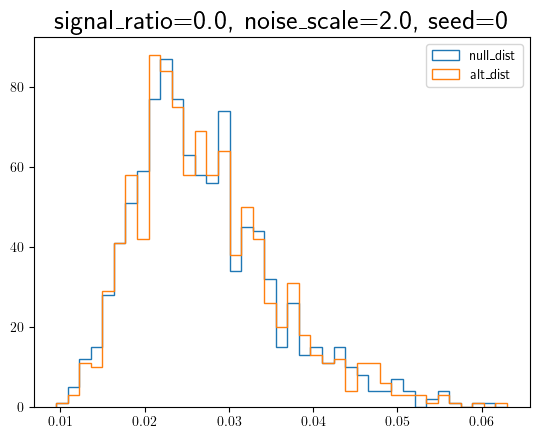

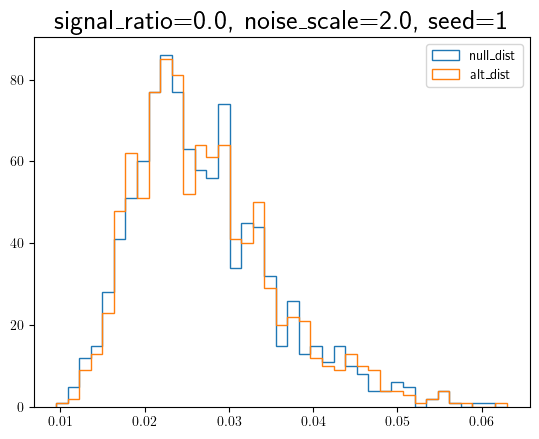

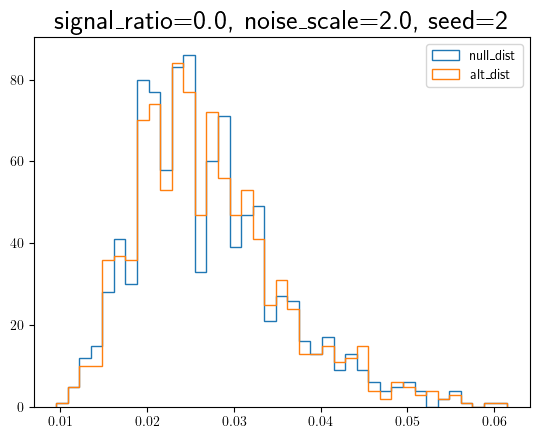

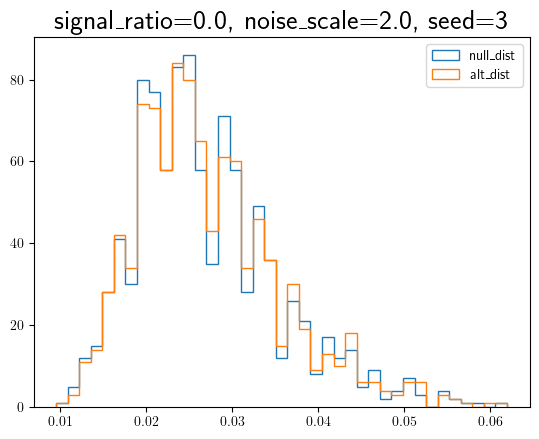

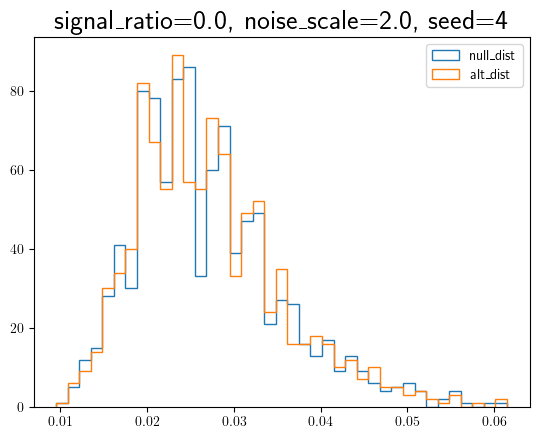

In [8]:
tmp_df = results_df_2[(results_df_2["signal_ratio"] == 0.0) 
                    & (results_df_2["SR_size"] == 0.2) 
                    & (results_df_2["noise_scale"] == 2.0)]
for i in range(5):
    alt_dist = tmp_df.iloc[i]["alt_dist"]
    null_dist = tmp_df.iloc[i]["null_dist"]
    bins = np.linspace(np.min(np.concatenate([alt_dist, null_dist])), 
                       np.max(np.concatenate([alt_dist, null_dist])), 40)
    plt.title(f"signal_ratio={tmp_df.iloc[i]['signal_ratio']}, noise_scale={tmp_df.iloc[i]['noise_scale']}, seed={tmp_df.iloc[i]['seed']}")
    plt.hist(null_dist, bins=bins, histtype="step", label="null_dist")
    plt.hist(alt_dist, bins=bins, histtype="step", label="alt_dist")
    # plt.axvline(x=np.random.choice(alt_dist), color="red", linestyle="--")
    plt.legend()
    plt.show()

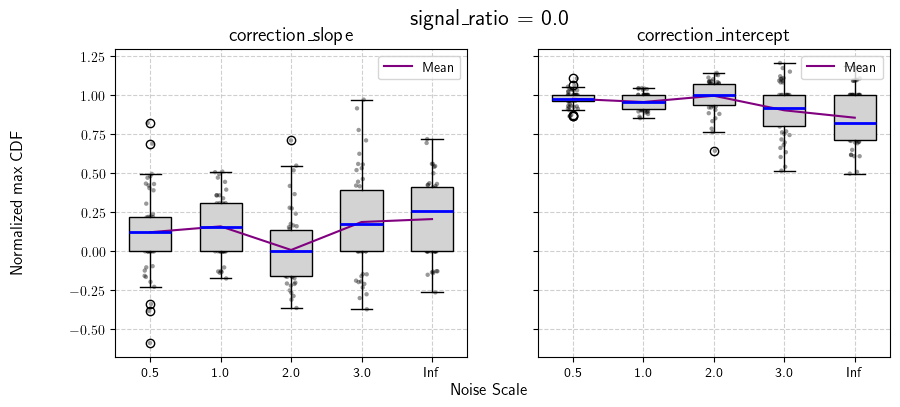

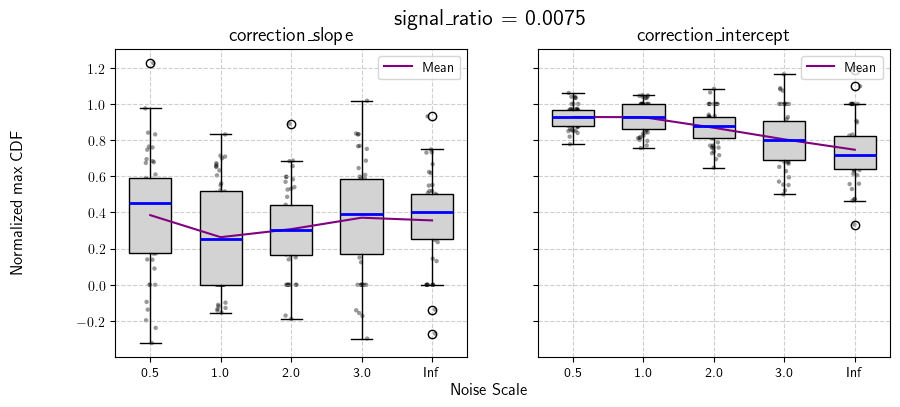

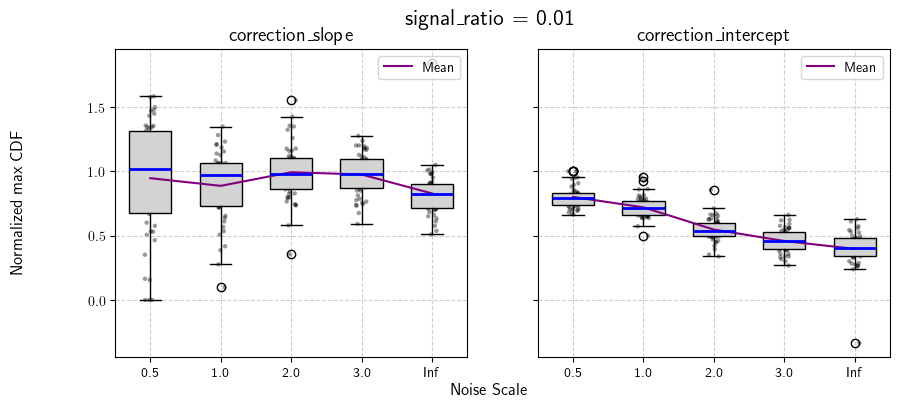

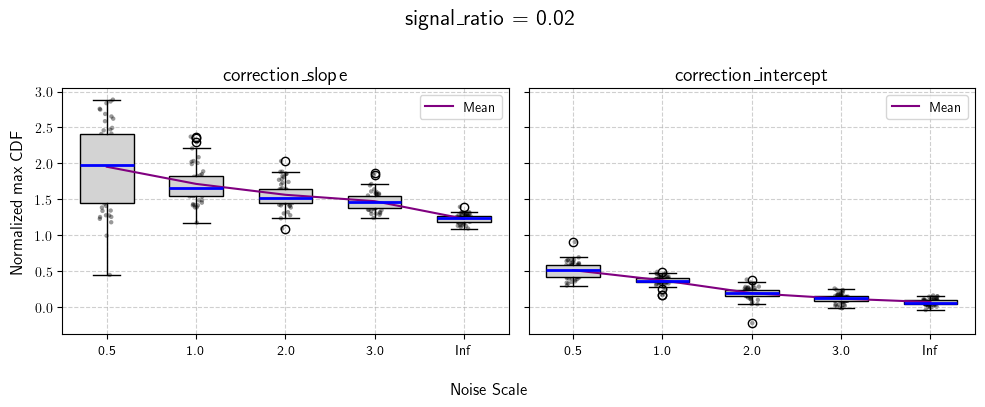

In [9]:
SR_size = 0.2
for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Normalized max CDF", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    # collect the data for each noise scale
    for i, key in enumerate(["correction_slope", "correction_intercept"]):
        ax = axs[i]
        
        data = []
        for ns in noise_scales:
            group = results_df.loc[
                (results_df["SR_size"] == SR_size) &
                (results_df["signal_ratio"] == signal_ratio) &
                (results_df["noise_scale"] == ns),
                key
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
            
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(key, fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


correction_slope_min: -0.017785602159370105, correction_slope_max: 0.8405348091258551
p-value: 0.758


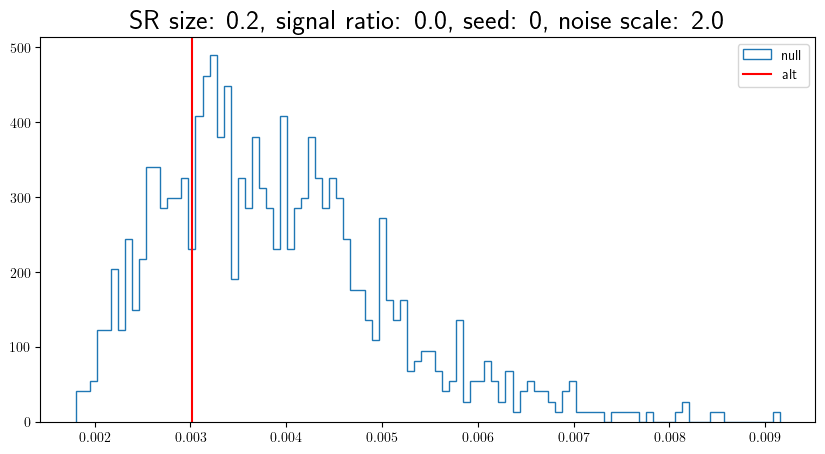

correction_slope_min: -0.008159040535875265, correction_slope_max: 0.8943766359866254
p-value: 0.279


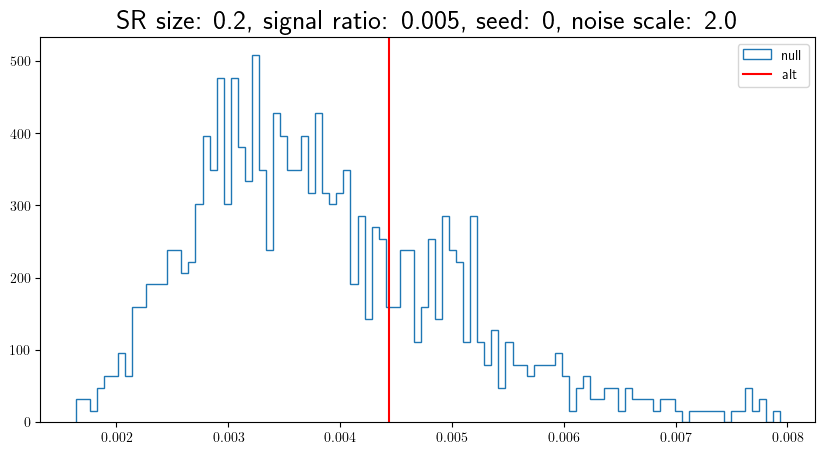

correction_slope_min: -0.02149075204269293, correction_slope_max: 0.7789076546922163
p-value: 0.314


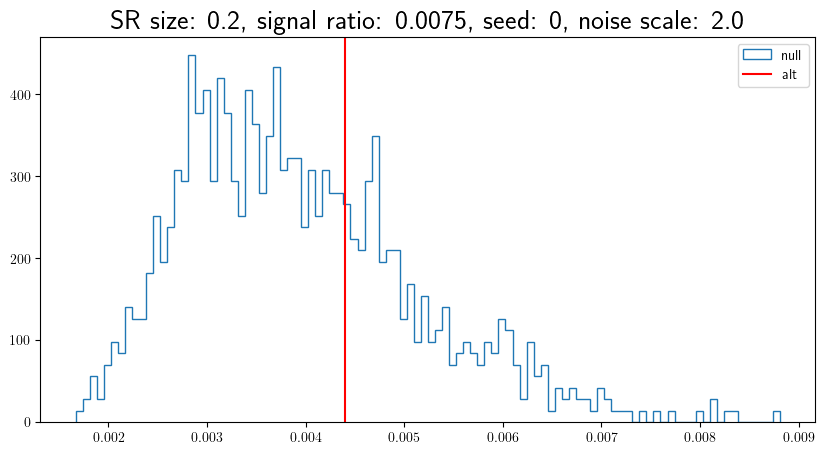

correction_slope_min: -0.012157405153837477, correction_slope_max: 1.0186047025575349
p-value: 0.0


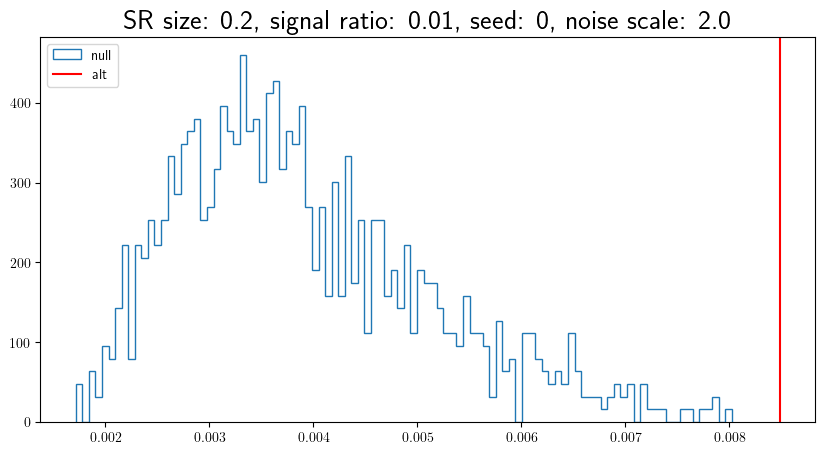

correction_slope_min: -0.06546400187244067, correction_slope_max: 1.9277207663996059
p-value: 0.0


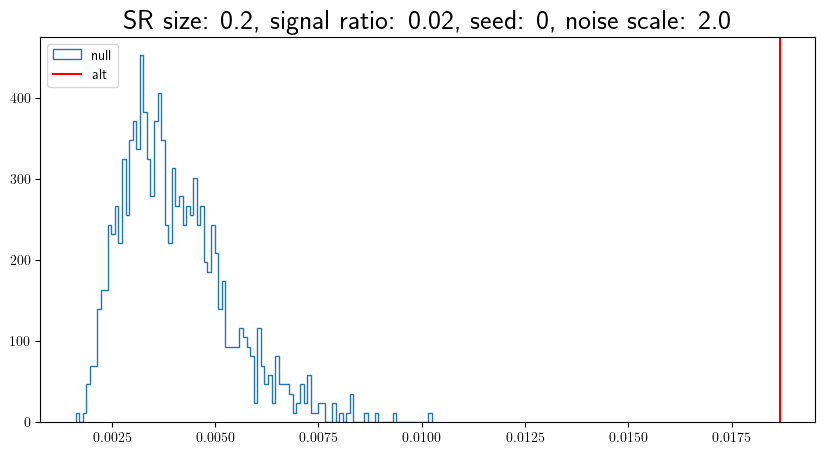

correction_slope_min: -0.011541845309227708, correction_slope_max: 0.9144609312130598
p-value: 0.838


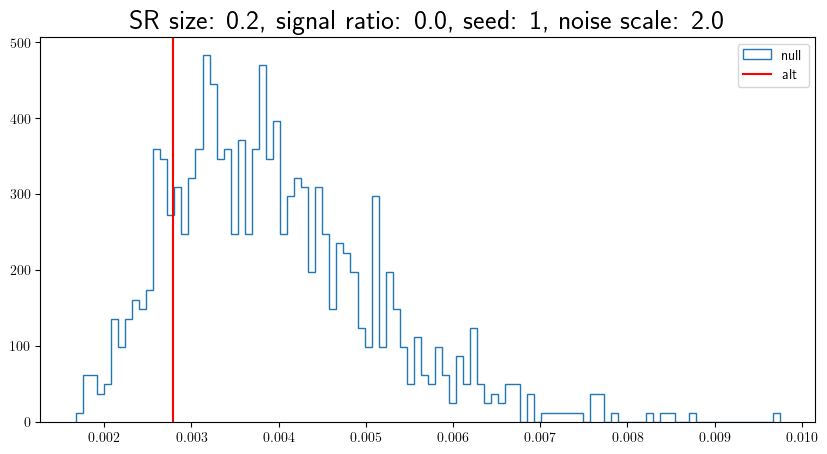

correction_slope_min: -0.012249296052379496, correction_slope_max: 0.947050847006038
p-value: 0.54


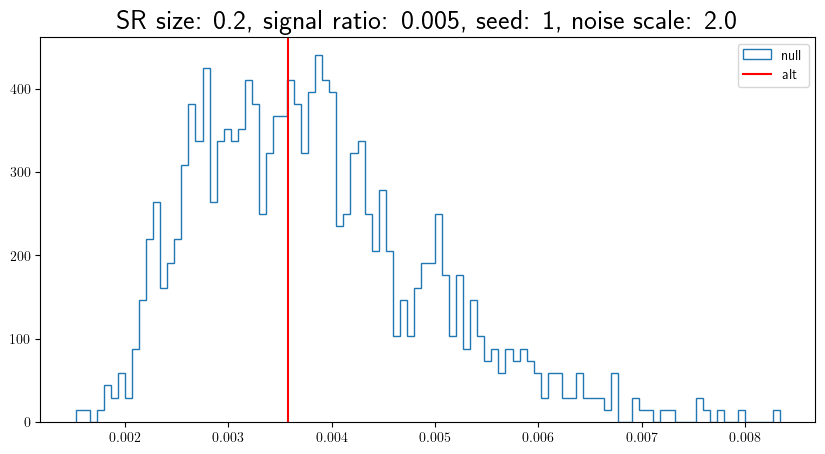

correction_slope_min: -0.02619649469587537, correction_slope_max: 1.0290680849471672
p-value: 0.063


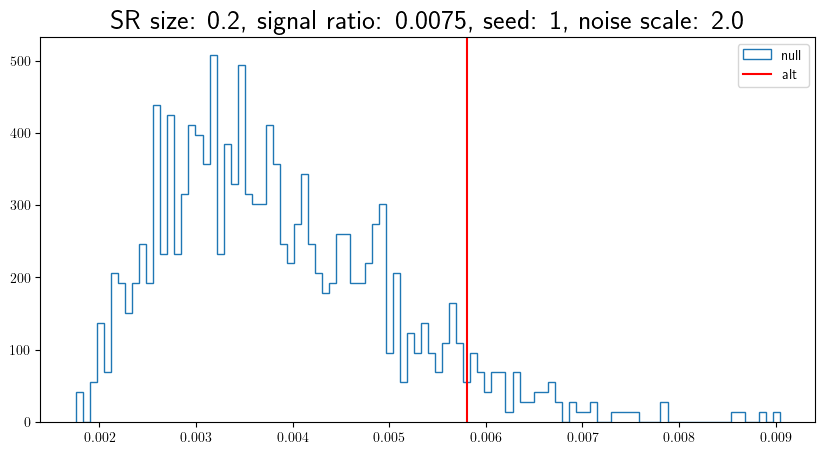

correction_slope_min: -0.024215001247957866, correction_slope_max: 1.019126492823108
p-value: 0.0


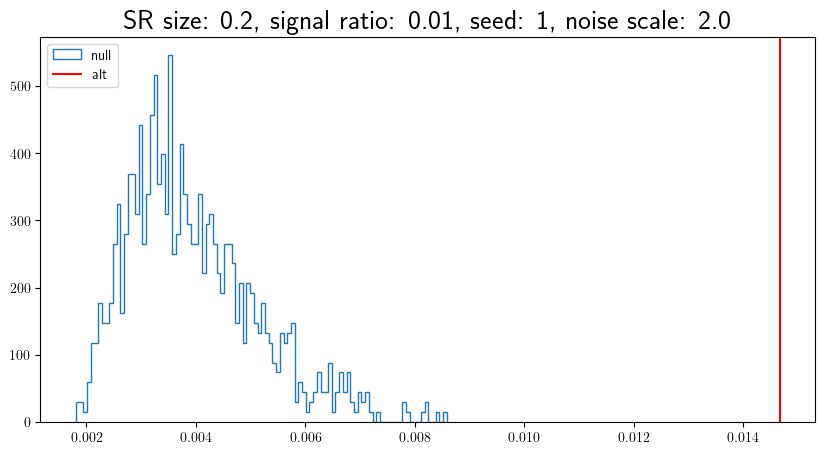

correction_slope_min: -0.05865894942023873, correction_slope_max: 2.139164522737654
p-value: 0.0


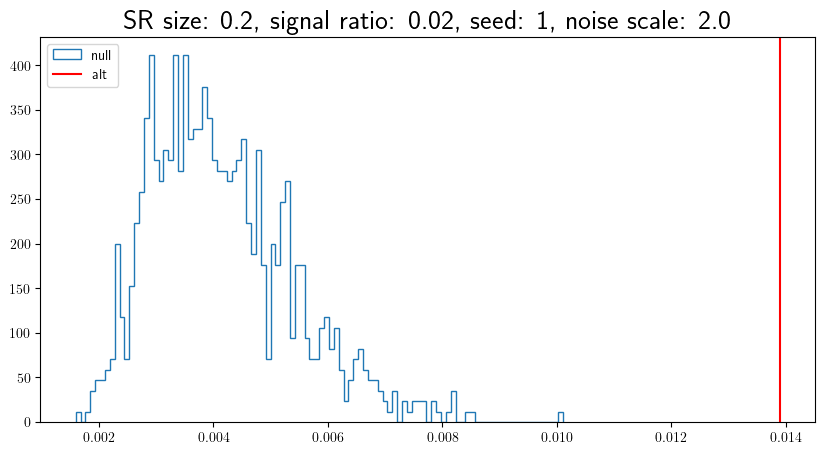

correction_slope_min: -0.014916114495107984, correction_slope_max: 0.8654060041494799
p-value: 0.579


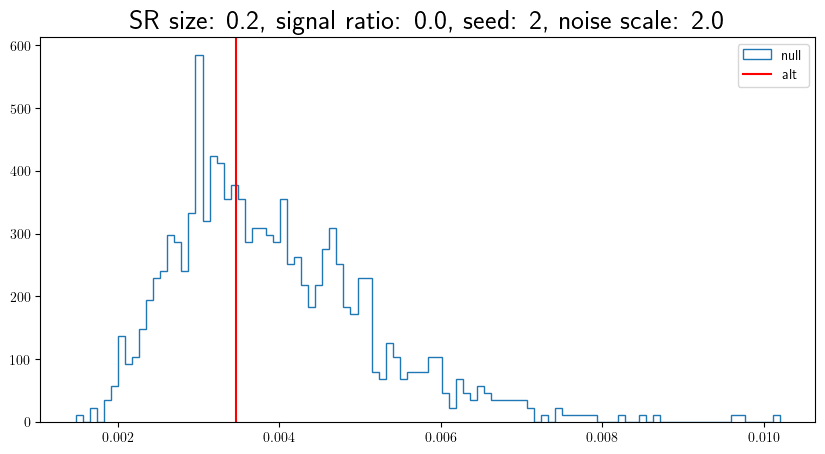

correction_slope_min: -0.020781162885476007, correction_slope_max: 0.7073089704358184
p-value: 0.359


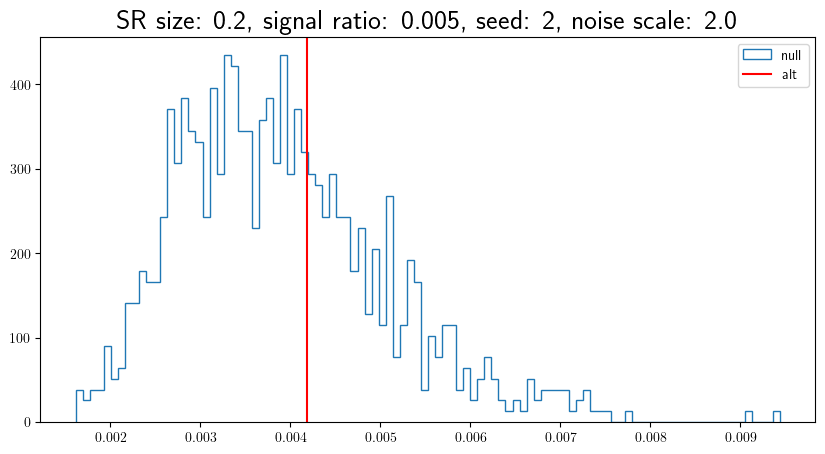

correction_slope_min: -0.011777200722417403, correction_slope_max: 0.9151359142339358
p-value: 0.293


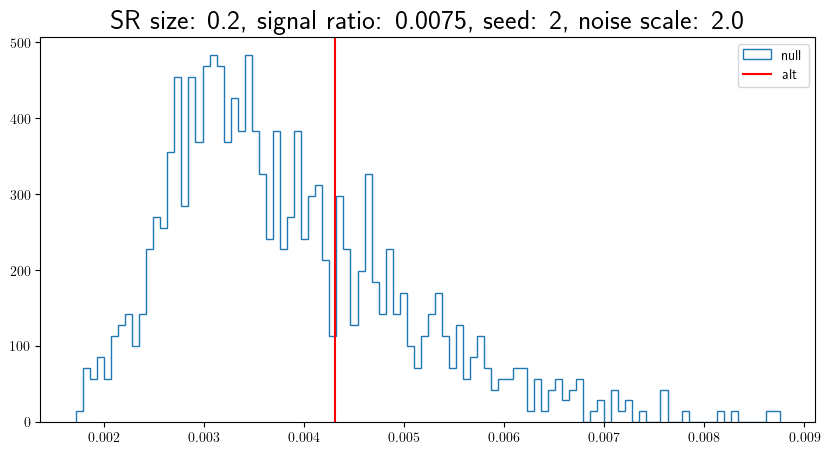

KeyboardInterrupt: 

In [3]:
from ks_poisson_bootstrap import alt_max_cdf_diff_bootstrap, null_max_cdf_diff_bootstrap
from ks_test import affine_correction, affine_tilt, normalize, max_cdf_diff

SR_size = 0.2
experiment_name = "CR_fvt_training_ensemble_max"

hashes = TrainingInfo.find(
    {
        "experiment_name": experiment_name,
        "signal_region": lambda x: x["4b_in_SR"] == SR_size,
    }
)

# sort by signal ratio and seed
signal_ratios = np.array([metadata[hash_]["dataset"]["signal_ratio"] for hash_ in hashes])
seeds = np.array([metadata[hash_]["dataset"]["seed"] for hash_ in hashes])
hashes = np.array(hashes)

hashes = hashes[np.lexsort((signal_ratios, seeds))]

for hash_ in hashes:
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    signal_filename = CR_fvt_tinfo.hparams["dataset"]["signal_filename"]
    
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]

    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        ensemble_mode,
        stats_type,
    )

    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    if noise_scale != 2.0:
        continue
    
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    
    SR_cut, CR_cut = get_SR_CR_cut(
        SR_stats_train,
        events_train,
        {"4b_in_SR": SR_size, "4b_in_CR": 1 - SR_size},
    )
    
    SR_stats_tst_SR = SR_stats_tst[SR_stats_tst >= SR_cut]
    events_tst_SR = events_tst[SR_stats_tst >= SR_cut]
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    reweights_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
    rw_tst_SR = np.where(events_tst_SR.is_4b, events_tst_SR.weights, 
                         reweights_tst_SR * events_tst_SR.weights)
    is_4b_tst_SR = events_tst_SR.is_4b
    
    stats_3b = SR_stats_tst_SR[~is_4b_tst_SR]
    stats_4b = SR_stats_tst_SR[is_4b_tst_SR]
    weights_3b_rw = rw_tst_SR[~is_4b_tst_SR]
    weights_4b_rw = rw_tst_SR[is_4b_tst_SR]
    
    correction_slope, correction_intercept = affine_correction(
        stats_3b,
        stats_4b,
        weights_3b_rw,
        weights_4b_rw,
        grid_size=0.01,
    )

    # stats_3b_mean = np.sum(rw_tst_SR * SR_stats_tst_SR) / np.sum(rw_tst_SR)
    # stats_3b_std = np.sqrt(
    #     np.sum(rw_tst_SR * (SR_stats_tst_SR - stats_3b_mean) ** 2)
    #     / np.sum(rw_tst_SR)
    # )

    # results = {
    #     "correction_slope": correction_slope,
    #     "correction_intercept": correction_intercept,
    #     "stats_3b_mean": stats_3b_mean,
    #     "stats_3b_std": stats_3b_std,
    # }

    null_max_cdf_diffs = null_max_cdf_diff_bootstrap(
        stats_3b,
        stats_4b,
        affine_tilt(
            stats_3b, weights_3b_rw, correction_slope, correction_intercept
        ),
        normalize(weights_4b_rw),
        n_reps=1000,
        random_seed=0,
        do_tqdm=False,
        n_jobs=4,   
    )

    alt_max_cdf_diff = max_cdf_diff(
        stats_3b,
        stats_4b,
        affine_tilt(
            stats_3b, weights_3b_rw, correction_slope, correction_intercept
        ),
        normalize(weights_4b_rw))

    print(f"p-value: {np.sum(null_max_cdf_diffs >= alt_max_cdf_diff) / len(null_max_cdf_diffs)}")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.set_title(f"SR size: {SR_size}, signal ratio: {signal_ratio}, seed: {seed}, noise scale: {noise_scale}")
    ax.hist(null_max_cdf_diffs, bins=100, density=True, label='null', histtype='step')
    ax.axvline(alt_max_cdf_diff, color='red', label='alt')
    ax.legend()
    plt.show()
    
    

# How Weights Look Like

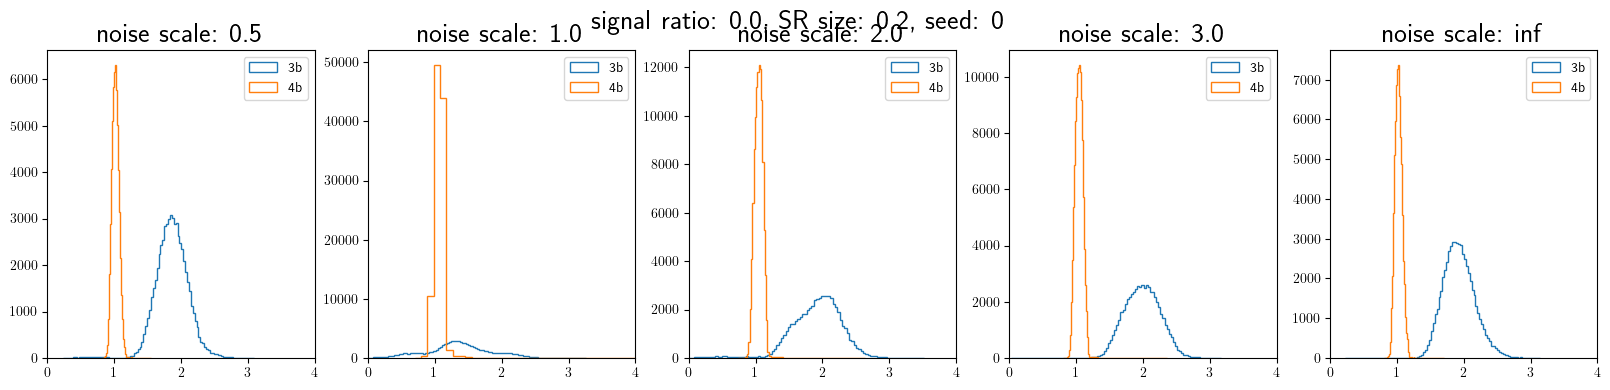

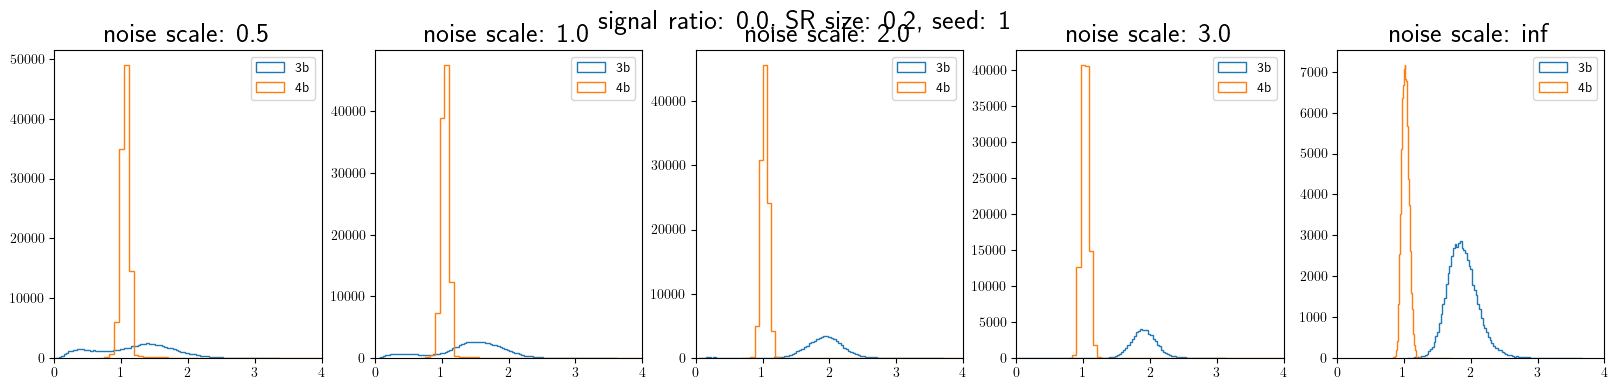

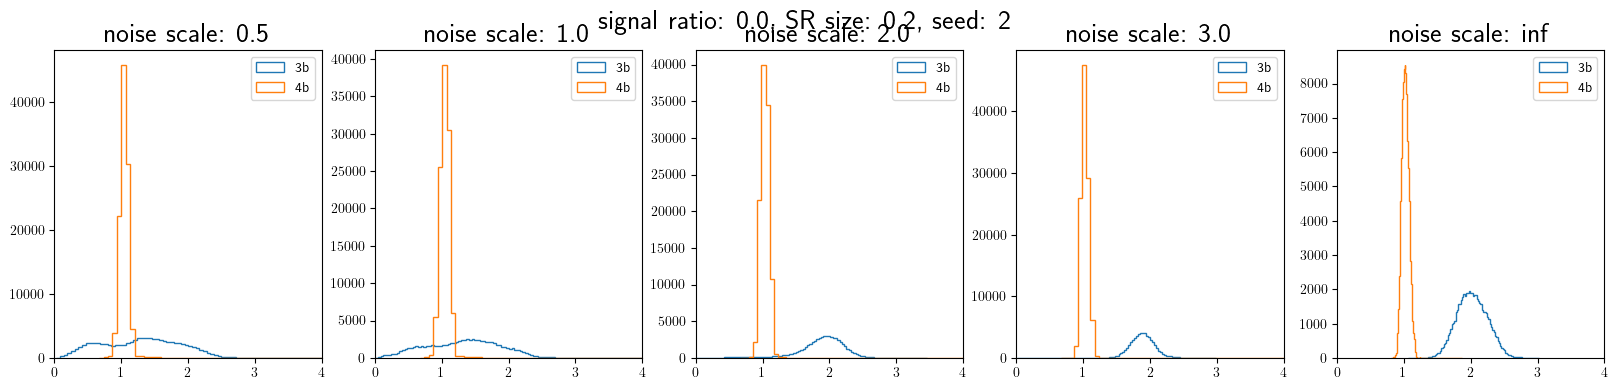

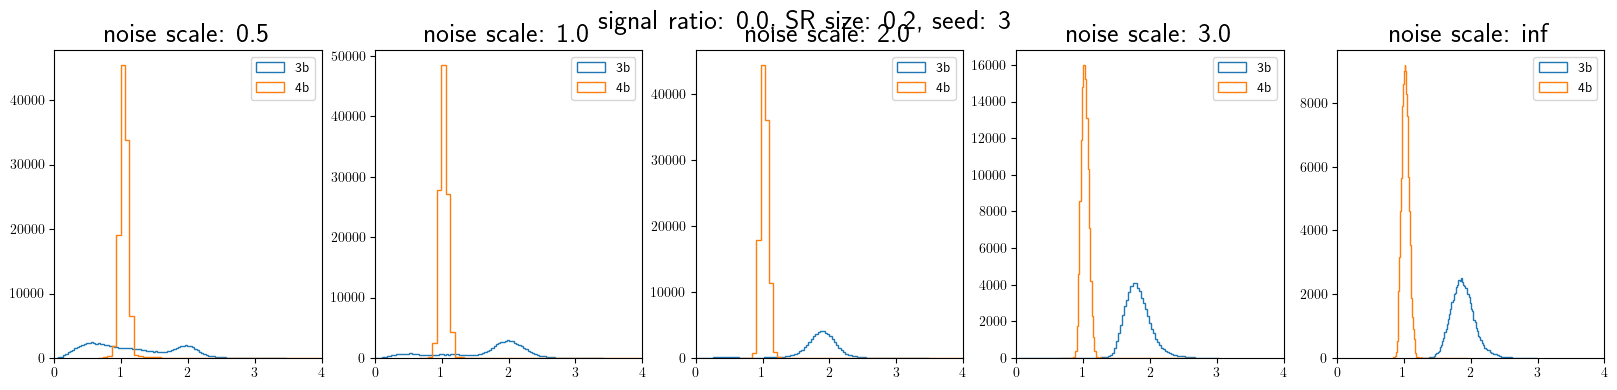

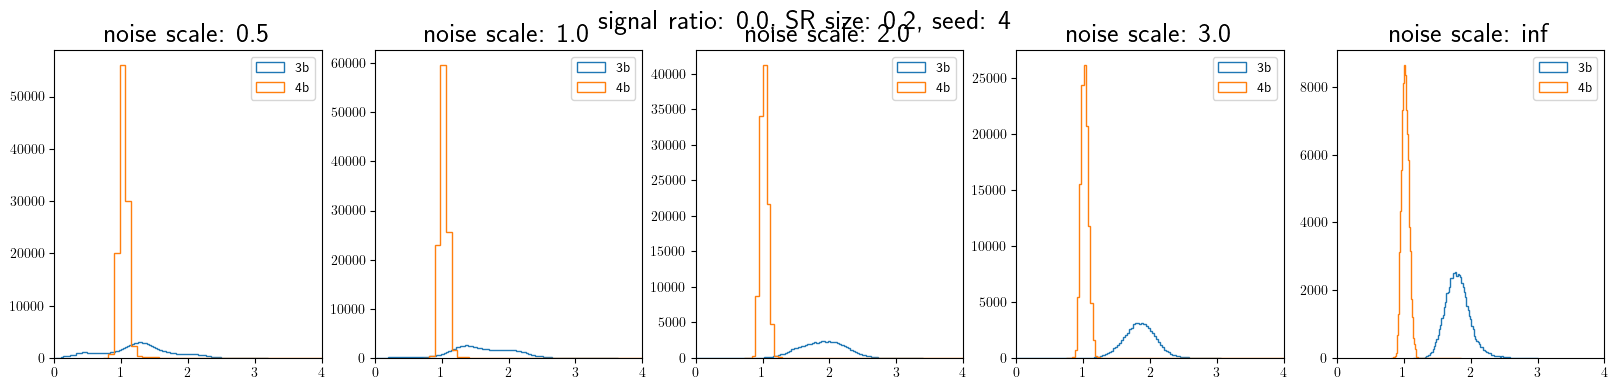

In [50]:
from ks_bootstrap import alt_max_cdf_diff_bootstrap, null_max_cdf_diff_bootstrap
from ks_test import empirical_cdf, affine_correction, affine_tilt, max_cdf_diff, normalize

SR_size = 0.2
signal_ratio = 0.0
experiment_name = "CR_fvt_training_ensemble_max"
seeds = range(5)

for seed in seeds:
    fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))
    fig.suptitle(f"signal ratio: {signal_ratio}, SR size: {SR_size}, seed: {seed}")
    hashes = TrainingInfo.find(
        {
            "experiment_name": experiment_name,
            "signal_region": lambda x: x["4b_in_SR"] == SR_size,
            "dataset": lambda x: (x["signal_ratio"] == signal_ratio) and (x["seed"] == seed),
        }
    )

    noise_scales_ = []
    for hash_ in hashes:
        SR_stats_hashes = metadata[hash_]["signal_region"]["SR_stats_hashes"]
        stats_type = metadata[hash_]["signal_region"]["stats_type"]
        smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        if stats_type == "fvt":
            noise_scale = np.inf
        noise_scales_.append(noise_scale)
    
    hashes = np.array(hashes)
    noise_scales_ = np.array(noise_scales_)
    sorted_indices = np.argsort(noise_scales_)
    hashes = hashes[sorted_indices]
    

    for i, hash_ in enumerate(hashes):
        ax = axs[i]
        CR_fvt_tinfo = TrainingInfo.load(hash_)
        SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
        ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
        stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
        signal_filename = CR_fvt_tinfo.hparams["dataset"]["signal_filename"]
        
        signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
        seed = CR_fvt_tinfo.hparams["dataset"]["seed"]

        SR_stats_train, SR_stats_tst = compute_sr_stats(
            SR_stats_hashes,
            signal_filename,
            ensemble_mode,
            stats_type,
        )

        smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        if stats_type == "fvt":
            noise_scale = np.inf
            
        msamples = MotherSamples.load(smeared_tinfo.ms_hash)
        events_train = events_from_scdinfo(
            msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
        )
        events_tst = events_from_scdinfo(
            msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
        )
        
        SR_cut, CR_cut = get_SR_CR_cut(
            SR_stats_train,
            events_train,
            {"4b_in_SR": SR_size, "4b_in_CR": 1 - SR_size},
        )
        
        SR_stats_tst_SR = SR_stats_tst[SR_stats_tst >= SR_cut]
        events_tst_SR = events_tst[SR_stats_tst >= SR_cut]
        fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
        reweights_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
        rw_tst_SR = np.where(events_tst_SR.is_4b, events_tst_SR.weights, 
                            reweights_tst_SR * events_tst_SR.weights)
        is_4b_tst_SR = events_tst_SR.is_4b
        
        stats_3b = SR_stats_tst_SR[~is_4b_tst_SR]
        stats_4b = SR_stats_tst_SR[is_4b_tst_SR]
        weights_3b_rw = rw_tst_SR[~is_4b_tst_SR]
        weights_4b_rw = rw_tst_SR[is_4b_tst_SR]
        
        ax.set_title(f"noise scale: {noise_scale}")
        ax.hist(weights_3b_rw, bins=100, histtype="step", label="3b")
        ax.hist(weights_4b_rw, bins=100, histtype="step", label="4b")
        ax.set_xlim(0, 4)
        ax.legend()
    plt.show()

In [4]:
from tqdm import tqdm
n_samples = 10000
n_reps = 1000
sig_level = 0.05
SB_sizes = [0.05, 0.1, 0.15]
SR_size = 0.2
experiment_name = "CR_fvt_training_ensemble_max"

hashes, hparams = TrainingInfo.find({"experiment_name": experiment_name, 
                                     "signal_region": lambda x: x["4b_in_SR"] == SR_size
                                     }, 
                                     return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

results = []

for hash_ in tqdm(hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
    
    for SB_size in SB_sizes:
        correction_results = CR_fvt_tinfo.aux_info[f"affine_correction_SB_size={SB_size}"]
            
        results.append({
            "seed": seed,
            "signal_ratio": signal_ratio,
            "SB_size": SB_size,
            "noise_scale": noise_scale,
            "correction_slope_SR": correction_results["correction_slope_SR"],
            "correction_intercept_SR": correction_results["correction_intercept_SR"],
            "correction_slope_SB": correction_results["correction_slope_SB"],
            "correction_intercept_SB": correction_results["correction_intercept_SB"],
            "stats_3b_std_SR": correction_results["stats_3b_std_SR"],
            "stats_3b_std_SB": correction_results["stats_3b_std_SB"],
            "stats_3b_mean_SR": correction_results["stats_3b_mean_SR"],
            "stats_3b_mean_SB": correction_results["stats_3b_mean_SB"],
        })

results_df = pd.DataFrame(results)

100%|██████████| 1250/1250 [00:38<00:00, 32.68it/s]


In [8]:
results_df["slope_normalized_SR"] = results_df["correction_slope_SR"] / results_df["stats_3b_std_SR"]
results_df["slope_normalized_SB"] = results_df["correction_slope_SB"] / results_df["stats_3b_std_SB"]

results_df[results_df["signal_ratio"] == 0.0].groupby(["signal_ratio", "noise_scale", "SB_size"]).agg({
    "slope_normalized_SR": "mean",
    "slope_normalized_SB": "mean",
})

slope_normalized_SR  slope_normalized_SB
signal_ratio noise_scale SB_size                                          
0.0          0.5         0.05                2.921633           166.141746
                         0.10                3.081357             7.830123
                         0.15                1.593475             9.931201
             1.0         0.05                3.258736            62.018705
                         0.10                3.186089             7.157458
                         0.15                3.201955             7.555436
             2.0         0.05                0.390510            69.480510
                         0.10                0.212238            -0.999171
                         0.15                0.422099             3.509515
             3.0         0.05                4.218351           -22.482213
                         0.10                5.330970             7.623047
                         0.15                5.172614             6.573659
             inf         0.05                3.060635            10.078406
                         0.10                3.545631             8.393873
                         0.15                0.001438             4.702658

In [20]:
results_df[results_df["signal_ratio"] == 0.0].groupby(["SR_size", "noise_scale"]).agg({
    "correction_slope_SR": "mean",
    "correction_intercept_SR": "mean",
    "correction_slope_SB": "mean",
    "correction_intercept_SB": "mean",
    "correction_ratio_SR": "mean",
    "correction_ratio_SB": "mean",
})

correction_slope_SR  correction_intercept_SR  \
SR_size noise_scale                                                 
0.2     0.5                     0.108628                 0.977483   
        1.0                     0.170896                 0.947045   
        2.0                    -0.003538                 1.001148   
        3.0                     0.195754                 0.887304   
        inf                     0.119620                 0.909996   

                     correction_slope_SB  correction_intercept_SB  \
SR_size noise_scale                                                 
0.2     0.5                     0.247905                 0.960030   
        1.0                     0.122000                 0.977057   
        2.0                     0.116106                 0.952955   
        3.0                     0.018673                 0.991299   
        inf                     0.207456                 0.864860   

                     correction_ratio_SR  correction_ratio_SB  
SR_size noise_scale                                            
0.2     0.5                     0.131772             1.958762  
        1.0                     0.213626             0.477277  
        2.0                     0.051541            -4.916818  
        3.0                     0.393450             1.601846  
        inf                     0.283681             0.564579

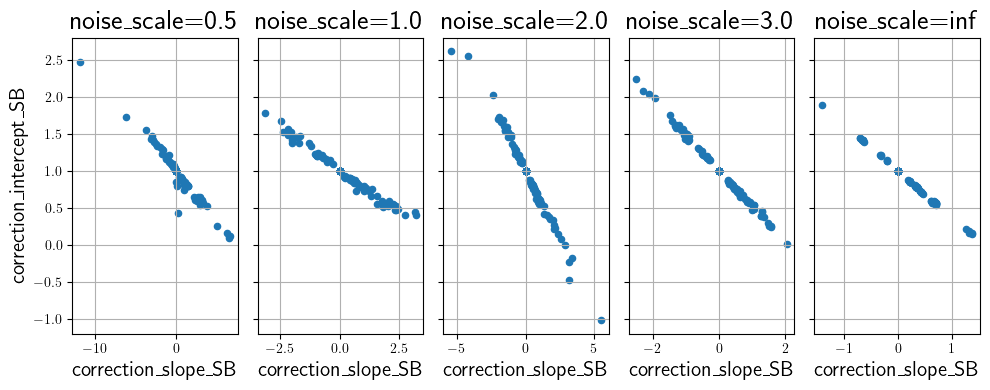

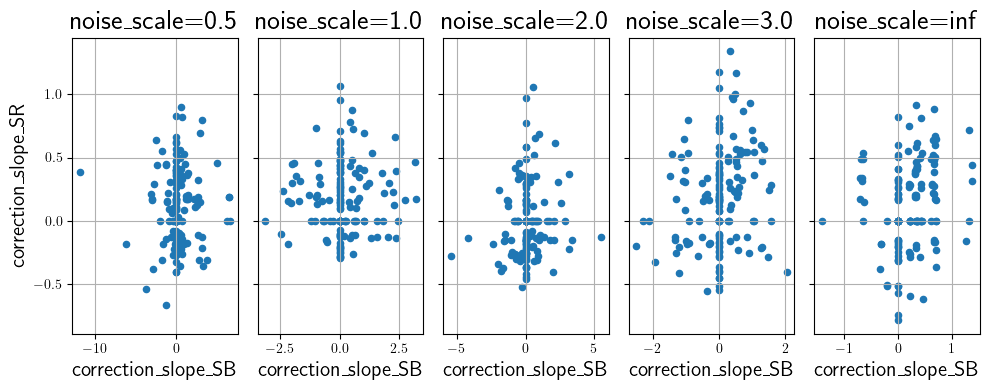

In [21]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(10, 4), sharey=True)
for i, noise_scale in enumerate([0.5, 1.0, 2.0, 3.0, np.inf]):
    ax = axs[i]
    results_df[(results_df["signal_ratio"] == 0.0)
               & (results_df["SR_size"] == 0.2)
               & (results_df["noise_scale"] == noise_scale)].plot(
                   x="correction_slope_SB",
                   y="correction_intercept_SB",
                   kind="scatter",
                   title=f"noise_scale={noise_scale}",
                   xlabel="correction_slope_SB",
                   ylabel="correction_intercept_SB",
                   grid=True,
                   legend=False,
                   ax=ax,
               )

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(10, 4), sharey=True)
for i, noise_scale in enumerate([0.5, 1.0, 2.0, 3.0, np.inf]):
    ax = axs[i]
    results_df[(results_df["signal_ratio"] == 0.0)
               & (results_df["SR_size"] == 0.2)
               & (results_df["noise_scale"] == noise_scale)].plot(
                   x="correction_slope_SB",
                   y="correction_slope_SR",
                   kind="scatter",
                   title=f"noise_scale={noise_scale}",
                   xlabel="correction_slope_SB",
                   ylabel="correction_slope_SR",
                   grid=True,
                   legend=False,
                   ax=ax,
               )

plt.tight_layout()
plt.show()

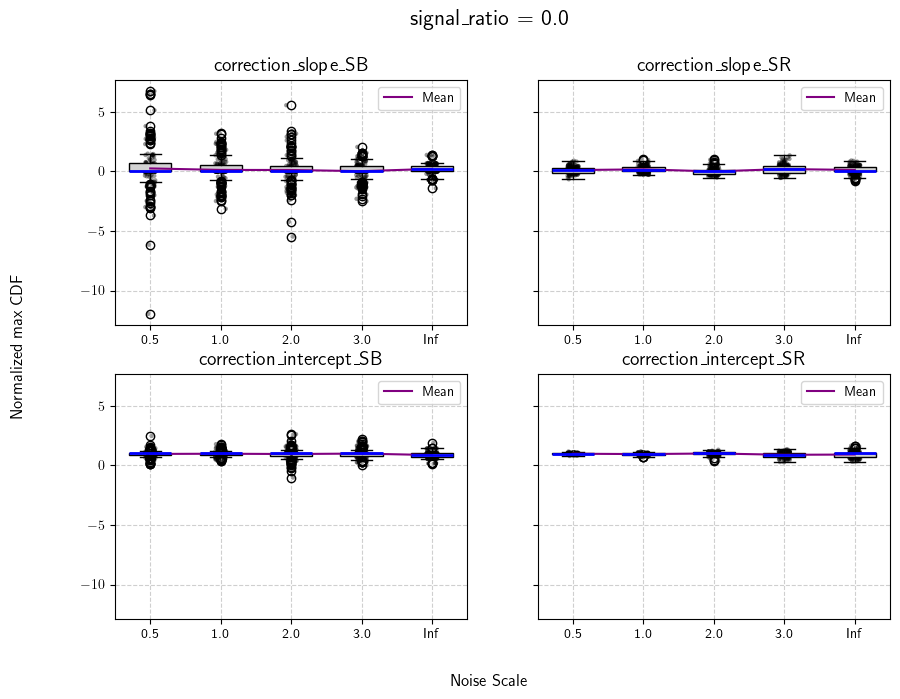

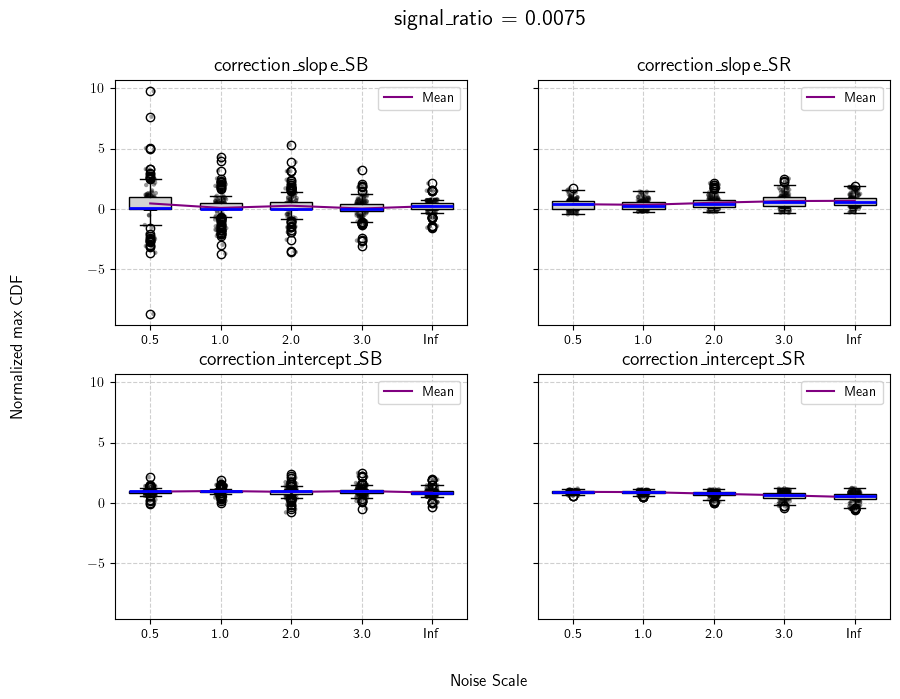

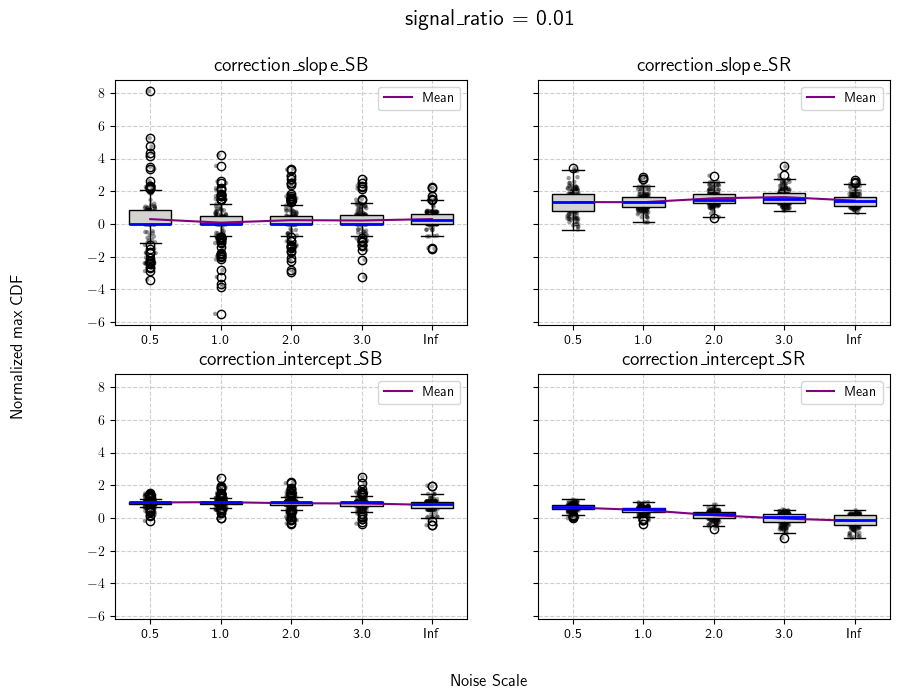

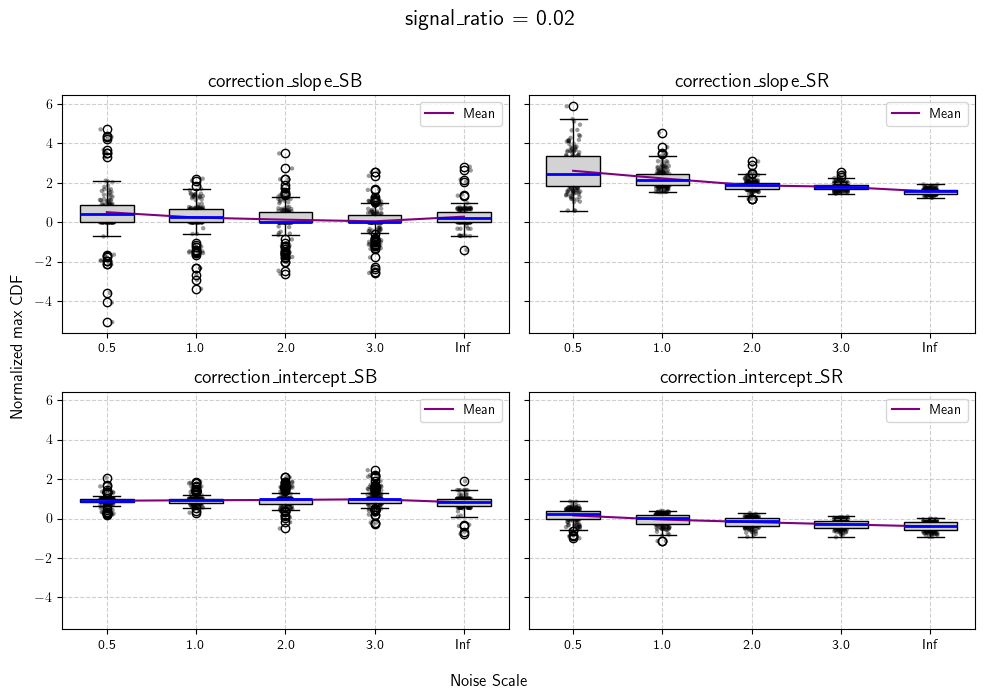

In [11]:
SR_size = 0.2
for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 7), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Normalized max CDF", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    axs_flat = axs.flatten()
    
    # collect the data for each noise scale
    for i, key in enumerate(["correction_slope_SB", "correction_slope_SR", 
                             "correction_intercept_SB", "correction_intercept_SR"]):
        ax = axs_flat[i]
        
        data = []
        for ns in noise_scales:
            group = results_df.loc[
                (results_df["SR_size"] == SR_size) &
                (results_df["signal_ratio"] == signal_ratio) &
                (results_df["noise_scale"] == ns),
                key
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
            
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(key, fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
